In [7]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import time
import sys
import pandas as pd
import sklearn.gaussian_process as gp
from IPython.display import display, Math

sys.path.append('../nn_model')
sys.path.append('..')

sys.path.append('../GP_regr')

import plot_settings
plot_settings.apply()
COLORS = plot_settings.colors()
import importlib
import SR_lib

import ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 as _lib



def import_reload():
    importlib.reload(plot_settings)
    importlib.reload(SR_lib)


from ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 import *
import_reload()

## Initial Setup

In [9]:
RUN_ID = 'SP'
DT = 1
Q0 = 17921.57581 
SAVE  = False
ITS = int(1.5e4)

REF_VALUES = SR_lib.get_ref_values()

UNITS = SR_lib.get_units_dict()


VARIABLES = ['R0', 'R1', 'C1','k']

N_VAR = len(VARIABLES)

SELECTION = "best"

In [10]:
model_name = '0515_0840_b4_combo_softplus_combo_V-dynamic_F-dynamic_unconstr_700.40min_16h_2500eps.pt'
BAT_MODEL, ckpt = load_nn_model(model_name)

df = pd.read_csv('lhs_samples_2.csv', usecols=['u_par', 'C_rate', 'SOC'])

s_data = pd.read_csv('combo_half.txt', delimiter=';')
#s_data = s_data[s_data['u_par', 'C', 'soc'].isin(df.values.tolist())]
f, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(df['u_par'],df['C_rate'], 'o')
ax[1].plot(df['u_par'],df['SOC'], 'o')
ax[2].plot(df['C_rate'],df['SOC'], 'o')

#display(df)
s_data_P = s_data[s_data['pulse'] == 1]

trajs = prepare_pulse_data(s_data_P)
s_df_p = data_param(BAT_MODEL, trajs, pulse = True)

s_data_CC = s_data[s_data['pulse'] == 0]
trajs = prepare_data(s_data_CC)
s_df_cc = data_param(BAT_MODEL, trajs, pulse = False)


FileNotFoundError: [Errno 2] No such file or directory: '/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/_moving_box/nn_model/models/0515_0840_b4_combo_softplus_combo_V-dynamic_F-dynamic_unconstr_700.40min_16h_2500eps.pt'

In [11]:

s_df_tot = pd.concat([s_df_p, s_df_cc], ignore_index=True)
s_data = s_df_tot[['I', 'u_per', 'soc', 's', 'sdot']]
s_data['C'] = s_data['I'].copy() * 3600/Q0 
REF_VALUES['s'] = np.max(s_data['s'].values)
s_data['s'] = s_data['s'].copy() / REF_VALUES['s']
s_data['C'] = s_data['C'].copy() / REF_VALUES['c_rate']
s_data['u_per'] = s_data['u_per'].copy() / REF_VALUES['u_per']

s_data['sdot'] = s_data['sdot'].copy() / REF_VALUES['sdot']

s_data.describe()

NameError: name 's_df_p' is not defined

In [5]:
def R0_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R0')

def R1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R1')

def C1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='C1')

def k_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='k')

def sdot_nn(c_rate, u_per, soc, s):
    return sdot_predict(BAT_MODEL, c_rate, u_per, soc, s)


def sample_element(c_rate, u_per, soc):
    R0 = R0_nn(c_rate, u_per, soc)
    R1 = R1_nn(c_rate, u_per, soc)
    C1 = C1_nn(c_rate, u_per, soc)
    k = k_nn(c_rate, u_per, soc)
    return R0.item(), R1.item(), C1.item(), k.item()


def generate_data(data, ref_values=REF_VALUES):
    samples = np.zeros((len(data),4+3))
    for row in trange(len(data)):
        u_per,c_rate, soc = data[row]
        r0, r1,c1,k = sample_element(c_rate, u_per, soc)
        samples[row] = [r0 / ref_values['R0'], r1/ ref_values['R1'], c1/ ref_values['C1'], k / ref_values['k'], c_rate, u_per, soc]
    return samples


In [6]:
samples = generate_data(df.values)

100%|██████████| 10000/10000 [00:08<00:00, 1238.96it/s]


In [7]:
# s_list = []; ds_list = []
# for i,tr in enumerate(trajs):
#     s, ds = _compute_element('s', tr['I_seq']*3600 / Q0, tr['u_per'], tr['soc'], source='nn')
#     s_list.append(s)
#     ds_list.append(ds)
#     print(f"traj {i} done")


In [8]:
cols = VARIABLES + ['C', 'u_per', 'soc']
df_samples = pd.DataFrame(samples, columns=cols)
data = df_samples
data['u_per'] =  data['u_per'] / REF_VALUES['u_per']
data['C'] =  data['C'] / REF_VALUES['c_rate']

data.describe() 

,R0,R1,C1,k,C,u_per,soc
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.823645,5.678430,9.447663,2.887359,0.499987,0.499977,0.499957
std,0.149276,10.257809,3.838857,0.377416,0.288700,0.288720,0.288703
min,0.400871,0.188216,0.123883,2.239312,0.000000,0.000000,0.000000
25%,0.744825,0.592013,10.566363,2.558353,0.249950,0.250008,0.250000
50%,0.809587,0.721194,11.240972,2.840583,0.500000,0.500017,0.500000
75%,0.877739,1.949865,11.378365,3.192075,0.750000,0.749958,0.750000
max,1.482466,28.958312,13.489980,3.777907,1.000000,0.999900,1.000000


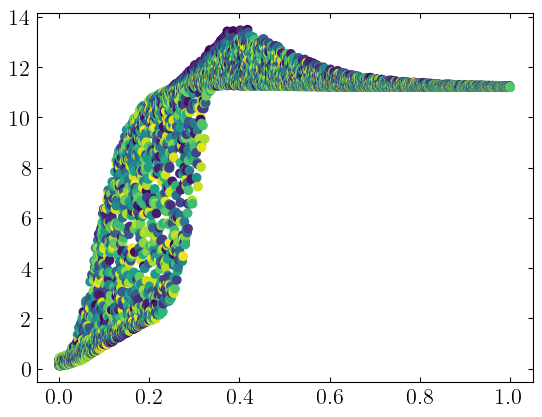

In [9]:
# plotting
arg_soc_sort = np.argsort(df_samples['soc'])
soc_sort = df_samples['soc'].values[arg_soc_sort]
R0_sort = df_samples['R0'].values[arg_soc_sort]
R1_sort = df_samples['R1'].values[arg_soc_sort]
C1_sort = df_samples['C1'].values[arg_soc_sort]
k_sort = df_samples['k'].values[arg_soc_sort]

#plt.plot(soc_sort, R0_sort, '-', label='R0')
#plt.plot(soc_sort, R1_sort, '-', label='R1')
plt.scatter(soc_sort, C1_sort, c = df_samples['u_per'].values[arg_soc_sort], label='C1')
#plt.plot(soc_sort, k_sort, '-', label='k')

# Importing data

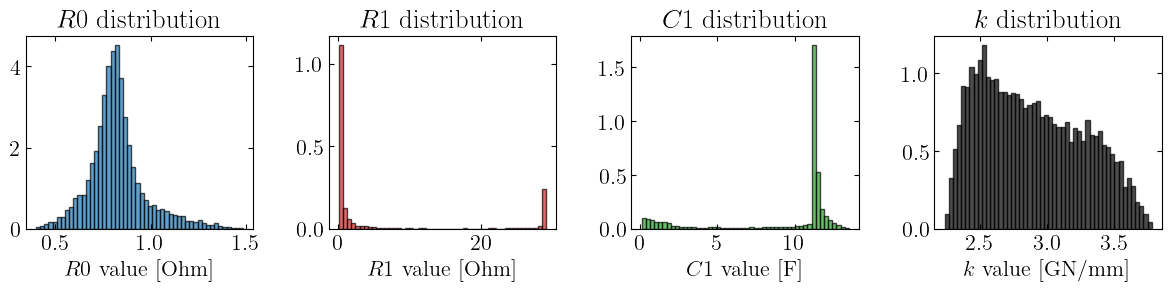

In [10]:
f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

for i, var in enumerate(VARIABLES):
    ax[i].hist(data[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
    ax[i].set_title(f'${var}$ distribution')
    ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
plt.tight_layout()
plt.show()

# f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

# for i, var in enumerate(VARIABLES):
#     ax[i].hist(data[var] / REF_VALUES[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
#     ax[i].set_title(f'${var}$ distribution')
#     ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
# plt.tight_layout()
# plt.show()

In [18]:
def get_XY(d_frame, s_frame = None):

    if s_frame is not None:
        for i in range(1,10):
            inds = np.arange(0,len(s_frame)) % i == 0
            if inds.sum() < 1e4:
                break

    X = d_frame[['C', 'u_per', 'soc']].values
    Y_R0 = d_frame['R0'].values #/ REF_VALUES['R0']
    Y_R1 = d_frame['R1'].values #/ REF_VALUES['R1']
    Y_C1 = d_frame['C1'].values #/ REF_VALUES['C1']
    Y_k  = d_frame['k'].values  #/ REF_VALUES['k']
    if s_frame is not None:
        Y_s = s_frame['sdot'].values  #/ REF_VALUES['s']
        X_s = s_frame[['C', 'u_per', 'soc', 's']].values
        Y_s = Y_s[inds]
        X_s = X_s[inds]
    else: 
        print('No s column found, using reference value for all samples')
        Y_s = np.ones_like(Y_k) * REF_VALUES['s']
        X_s = np.ones_like(X)
    
    return X,Y_R0, Y_R1 ,Y_C1, Y_k, Y_s, X_s

In [ ]:
split_train = int(len(data) * 0.99)
s_split_train = int(len(s_data) * 0.99)

# randomize trajectories before splitting into train and test sets

randomize = False
if randomize:
    data_rand = data.copy()
    data_rand['trajectory'] = np.random.permutation(data_rand['trajectory'].values)
    data_train  = data_rand[data_rand['trajectory'] <= split_train]
    data_test   = data_rand[data_rand['trajectory'] > split_train]
    trajs_train = SR_lib.prepare_data(data_train)
    trajs_test  = SR_lib.prepare_data(data_test)
else:
    data_train  = data#[:split_train]
    data_test   = data#[split_train:]
    s_data_train = s_data#[:s_split_train]
    s_data_test = s_data#[s_split_train:]
X_train, YR0_train, YR1_train, YC_train, Yk_train, Ys_train, Xs_train = get_XY(data_train, s_frame = s_data_train)

X_test, YR0_test, YR1_test, YC_test, Yk_test, Ys_test, Xs_test = get_XY(data_test, s_frame = s_data_test)

Y_train_dict = {
    'R0': YR0_train,
    'R1': YR1_train,
    'C1': YC_train,
    'k':  Yk_train,
    's':  Ys_train
}
Y_test_dict = {
    'R0': YR0_test,
    'R1': YR1_test,
    'C1': YC_test,
    'k':  Yk_test,
    's':  Ys_test
}

# u_C_pairs_train = data_train.loc[data_train['t'] == 0, ['u_par', 'C','trajectory']]
# u_C_pairs_test = data_test.loc[data_test['t'] == 0, ['u_par', 'C','trajectory']]


# plt.scatter(u_C_pairs_train['C'], u_C_pairs_train['u_par'],c= colors[0], label='Train')
# plt.scatter(u_C_pairs_test['C'], u_C_pairs_test['u_par'],  c= colors[1], label='Test')
# plt.xlabel('C-rate [a.u.]')
# plt.ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
# plt.vlines(0.5,0,30, color='gray', linestyle='--')
# plt.vlines(5,0,30, color='gray', linestyle='--')
# plt.hlines(0,0.5,5, color='gray', linestyle='--')
# plt.hlines(30,0.5,5, color='gray', linestyle='--')
# plt.fill_between([0.5, 5], 0, 30, color='tab:blue', alpha=0.1)
# plt.legend(ncol = 2,loc='upper center', bbox_to_anchor=(0.5, 1.15))


# $R_0 = f_{R_0}(i,d,\mathrm{SOC})$

Variable names for element R0: ['C', 'd', 'soc']
Running symbolic regression for element R0 with run_id R0_1505_knight...
Settings: iterations=15000, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.022280978
Equation: 0.8236666

Model 1: Complexity=3, Loss=0.0149950655
Equation: soc ^ soc

Model 2: Complexity=5, Loss=0.009113717
Equation: sqrt(cube(soc) + 0.46444154)

Model 3: Complexity=6, Loss=0.0065346826
Equation: -1.7592791 / (cube(soc) + -2.430771)

Model 4: Complexity=7, Loss=0.0063878973
Equation: sqrt(-0.7938481 / (cube(soc) + -1.4862007))

Model 5: Complexity=8, Loss=0.004222212
Equation: sqrt(exp(cube(soc)) / (C + 1.4774152))

Model 6: Complexity=9, Loss=0.0039112465
Equation: sqrt(exp(square(square(soc))) / (C + 1.3794612))

Model 7: Complexity=10, Loss=0.0030735997
Equation: sqrt(exp(cube(soc)) / (1.6884543 + (C * d)))

Model 8: Complexity=11, Loss=0.0019975628
Equation: sqrt(cube(square(soc)) + (0.6976577 / (exp(d) ^ C)))

Model 9: Complexity=12, Loss=0.0019883984
Equation: sqrt((((0.3851084 ^ C) ^ d) * 0.6912418) + cube(square(soc)))

Model 10: Complexity=13, Loss=0.0018814976
Equation: sqrt((0.72836936 / ((exp(d) + 0.1471553) ^ C)) + 

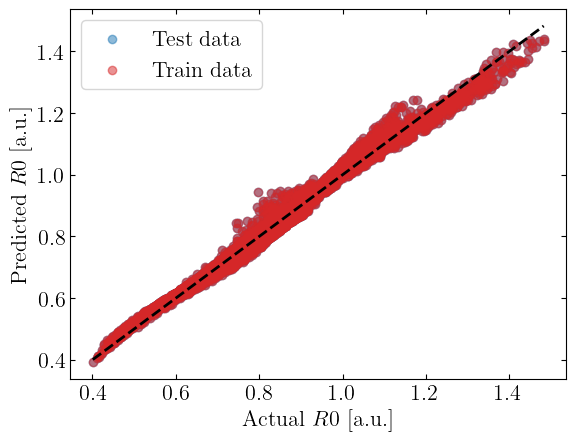

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: 0.67845374**C*(d*(-0.08299903) + soc**9 + soc + (-soc + (0.65237767**d + soc)**C)**2)**0.5677224
Loss: 0.000281249
Best model complexity: 26


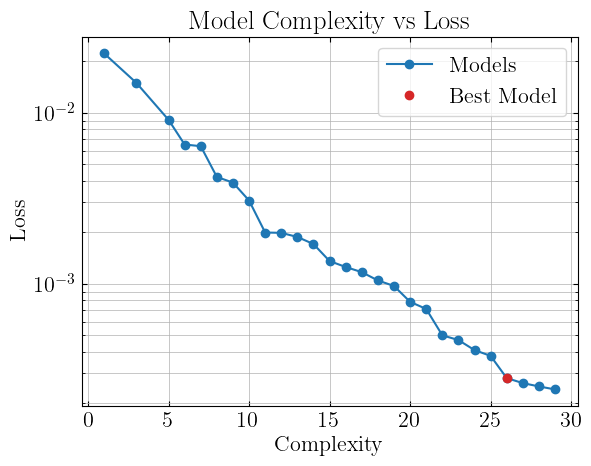

In [ ]:
import_reload()
model_R0 = SR_lib.run_symbolic_regression(X_train, YR0_train, model = None,run_id = f'R0_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'R0')
df_model_R0 = model_R0.equations_
SR_lib.print_models(df_model_R0)
import_reload() 
SR_lib.parity_plot('R0',model_R0, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')
SR_lib.print_best_model(model_R0)
SR_lib.pareto_plot(model_R0)

# $R_1 = f_{R_1}(i,d,\mathrm{SOC})$

Variable names for element R1: ['C', 'd', 'soc']
Running symbolic regression for element R1 with run_id R1_1505_knight...
Settings: iterations=15000, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=105.21213
Equation: 5.677226

Model 1: Complexity=3, Loss=97.5085
Equation: C * 10.947096

Model 2: Complexity=4, Loss=71.9835
Equation: cube(2.3559144 - soc)

Model 3: Complexity=5, Loss=37.979225
Equation: (1.5502335 - soc) ^ 7.9770174

Model 4: Complexity=6, Loss=36.80544
Equation: exp(4.416173 - (28.00609 ^ soc))

Model 5: Complexity=7, Loss=22.606527
Equation: cube(C + cube(1.3928927 - soc))

Model 6: Complexity=8, Loss=18.697075
Equation: cube(cube(1.486712 - square(soc ^ C)))

Model 7: Complexity=9, Loss=8.975791
Equation: exp(3.5398505 - cube((8.005652 ^ soc) - C))

Model 8: Complexity=10, Loss=2.8222008
Equation: exp(3.37164 - (((7.810039 ^ soc) - C) ^ 12.346904))

Model 9: Complexity=11, Loss=2.494874
Equation: exp(exp(1.2144606 - (((7.0995107 ^ soc) - C) ^ 19.581877)))

Model 10: Complexity=12, Loss=1.7337157
Equation: exp(3.3752503 - cube((cube(soc ^ C) * 66.57915) * soc))

Model 11: Complexity=13, Loss=1.284358
Equation: exp(exp(1.2176114 - cube

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: (exp(1.5018007 - soc**4.4675528*(soc**(2*C)*51.3012 - 3.9479158)**4) - 1.6056911)**3 + 4.913326
Loss: 0.31504977
Best model complexity: 22


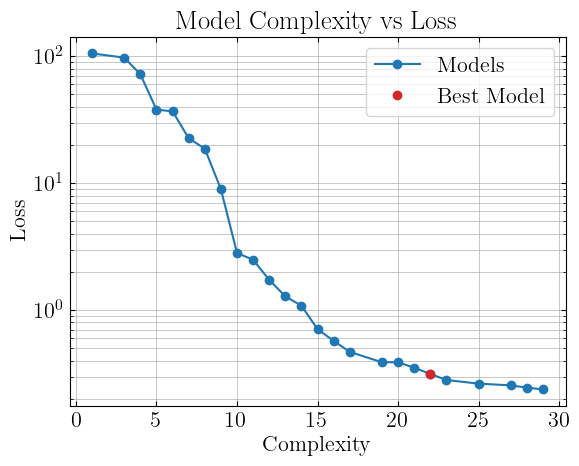

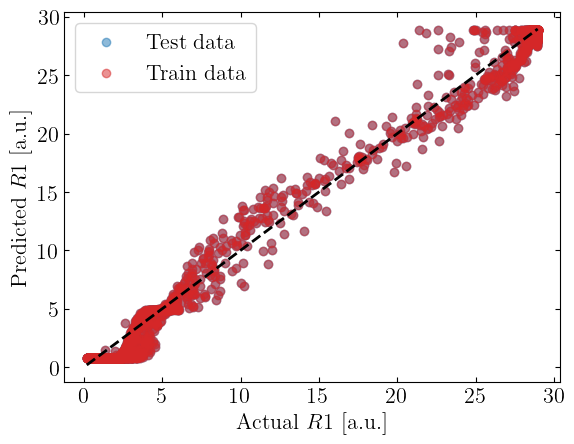

In [ ]:
import_reload()
model_R1 = SR_lib.run_symbolic_regression(X_train, YR1_train, model = None,run_id = f'R1_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'R1')
df_model_R1 = model_R1.equations_
SR_lib.print_models(df_model_R1)
SR_lib.print_best_model(model_R1)
SR_lib.pareto_plot(model_R1)
SR_lib.parity_plot('R1',model_R1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $C_1 = f_C(i,u,\mathrm{SOC})$

Variable names for element C1: ['C', 'd', 'soc']
Running symbolic regression for element C1 with run_id C1_1505_knight...
Settings: iterations=15000, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=14.73535
Equation: 9.447384

Model 1: Complexity=3, Loss=13.298023
Equation: soc + 8.946838

Model 2: Complexity=4, Loss=5.70297
Equation: sqrt(soc * 196.58856)

Model 3: Complexity=6, Loss=3.7141883
Equation: soc * cube(3.2920573 - soc)

Model 4: Complexity=7, Loss=2.5965664
Equation: cube(cube(soc - 1.3532758)) + 11.507891

Model 5: Complexity=8, Loss=1.915815
Equation: cube(cube(1.3122306 - exp(soc / -0.07228787)))

Model 6: Complexity=9, Loss=1.6620476
Equation: cube(2.27319 - exp((soc / -0.12288528) + C))

Model 7: Complexity=10, Loss=0.5129126
Equation: cube(2.252624 - exp(cube(C + (soc / -0.1327819))))

Model 8: Complexity=11, Loss=0.4397098
Equation: exp(cube(1.3476334 - cube(exp((soc / -0.15324993) + C))))

Model 9: Complexity=12, Loss=0.2794024
Equation: exp(cube(1.3464677 - exp(((C * -0.20096038) + soc) / -0.038954653)))

Model 10: Complexity=13, Loss=0.20784493
Equation: cube(exp(0.8129938 - exp(cube((soc / -0.17916153) + (C - 0.6195835)))))

Mod

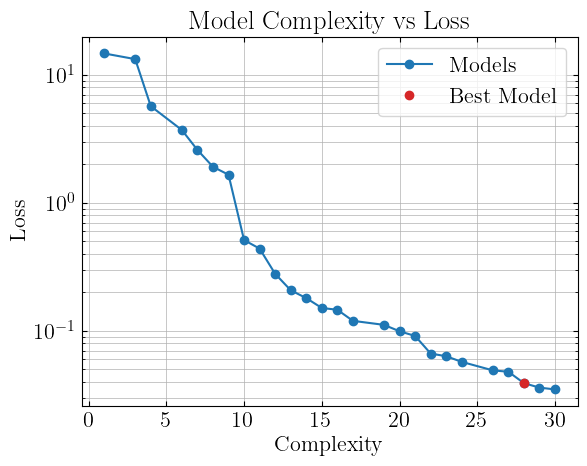

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: (C**(1/4) - 1.79918038702609*soc**2 + soc)**6 + 11.1765406861133*exp(-5.68286211893661*exp(C*(C + 4.8734035) - 26.0609938797841*soc))
Loss: 0.039071906
Best model complexity: 28


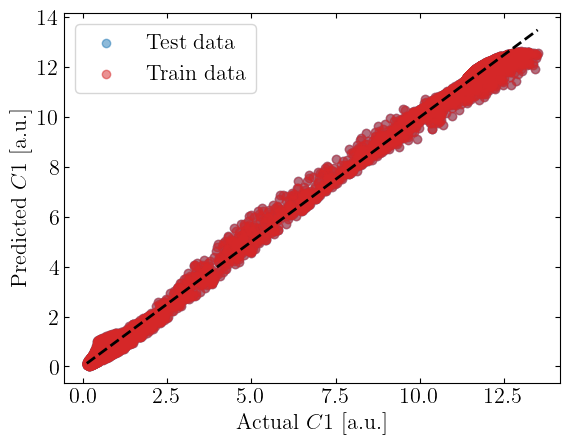

In [ ]:
import_reload()
model_C1 = SR_lib.run_symbolic_regression(X_train, YC_train, model = None,run_id = f'C1_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'C1')
df_model_C1 = model_C1.equations_
SR_lib.print_models(df_model_C1)
SR_lib.pareto_plot(model_C1)
SR_lib.print_best_model(model_C1)
SR_lib.parity_plot('C1', model_C1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $k = f_k(i,d,\mathrm{SOC})$

Variable names for element k: ['C', 'd', 'soc']
Running symbolic regression for element k with run_id k_1505_knight...
Settings: iterations=15000, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.14242895
Equation: 2.8874736

Model 1: Complexity=3, Loss=0.015178809
Equation: d + 2.387419

Model 2: Complexity=4, Loss=0.01498468
Equation: square(d) + 2.5540168

Model 3: Complexity=5, Loss=0.007930156
Equation: 6.5900126 / (2.8187299 - d)

Model 4: Complexity=6, Loss=0.007911483
Equation: (2.2779224 ^ d) + 1.3350477

Model 5: Complexity=7, Loss=0.0015060091
Equation: (7.2816586 - soc) / (2.88264 - d)

Model 6: Complexity=8, Loss=0.0006708763
Equation: (7.3122253 - sqrt(soc)) / (2.8370485 - d)

Model 7: Complexity=9, Loss=8.2227394e-05
Equation: 6.5791454 / (((soc * 0.23025405) + 2.7015586) - d)

Model 8: Complexity=10, Loss=7.5322656e-05
Equation: (10.02157 - soc) / ((3.2452033 - d) ^ 1.1961082)

Model 9: Complexity=11, Loss=4.7016034e-05
Equation: (8.493054 / ((soc * 0.23251861) + (3.0020673 - d))) + -0.39861524

Model 10: Complexity=12, Loss=4.1436924e-05
Equation: square(6.095922 / (((soc * 0.23289427) + 4.294957) - d)) + 0.41614494

Model 11: Comp

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: d*0.5045464 + (soc**0.9353952 - exp(d))*(d**6*soc**soc*0.19117777 - (d + 0.8601193))/4.407675 + 2.2418108
Loss: 8.120605e-06
Best model complexity: 30


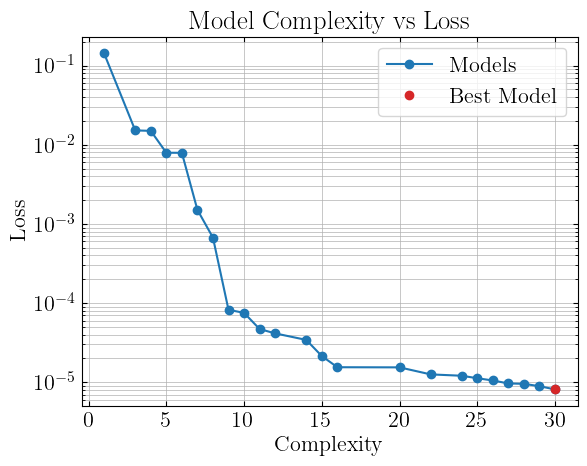

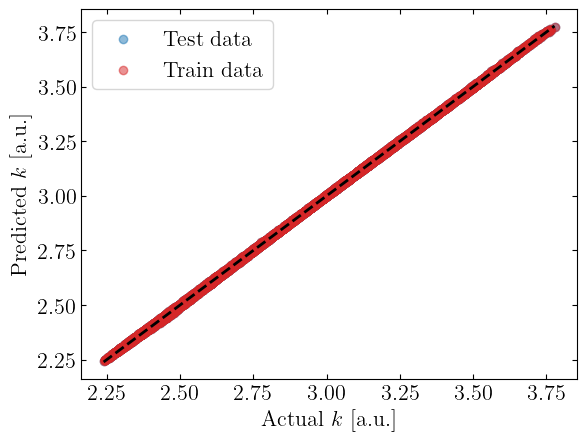

In [ ]:
import_reload()
model_k = SR_lib.run_symbolic_regression(X_train, Yk_train, model = None,run_id = f'k_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'k')
df_model_k = model_k.equations_
SR_lib.print_models(df_model_k)
SR_lib.print_best_model(model_k)
SR_lib.pareto_plot(model_k)
SR_lib.parity_plot('k',model_k, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $\dot s = f_s(s,i,d,\mathrm{SOC})$

Variable names for element s: ['C', 'd', 'soc', 's']
Running symbolic regression for element s with run_id s_1505_knight...
Settings: iterations=15000, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=1.0071614
Equation: C

Model 1: Complexity=2, Loss=0.7823736
Equation: exp(C)

Model 2: Complexity=3, Loss=0.38231897
Equation: C * 3.0203295

Model 3: Complexity=4, Loss=0.36027333
Equation: exp(C) - d

Model 4: Complexity=5, Loss=0.17556557
Equation: C / (d + 0.1728967)

Model 5: Complexity=6, Loss=0.014491036
Equation: C / (cube(d) + 0.21142976)

Model 6: Complexity=7, Loss=0.00871193
Equation: C * ((1.065626 - d) * 4.8696294)

Model 7: Complexity=8, Loss=0.0083296485
Equation: (9.039628 - square(d + 1.9869642)) * C

Model 8: Complexity=9, Loss=0.0069687795
Equation: C * square(square(-0.3164983 - d) + -2.3485088)

Model 9: Complexity=10, Loss=0.006567859
Equation: ((1.0482166 - d) * C) * (5.181952 - square(s))

Model 10: Complexity=11, Loss=0.006339064
Equation: C * (square(square(d - -0.3520165) + -2.4766142) - s)

Model 11: Complexity=12, Loss=0.005083235
Equation: (square(-2.4031405 + square(d - -0.340936)) - cube(s)) * C

Model 12: Complexity=14, Los

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: (C - 1*(-0.022683699))**1.0600445*(-(0.3135911 - d**3)*(1.3893673 - soc)**3 + (2.0655236 - d)*(2.5143425 + d**2*(-2.6057615)))
Loss: 0.002125786
Best model complexity: 27


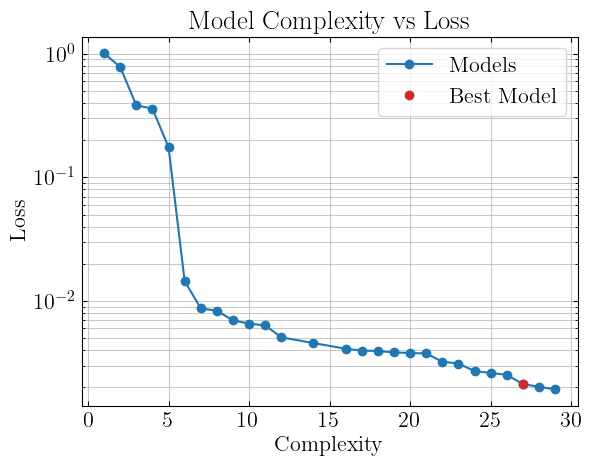

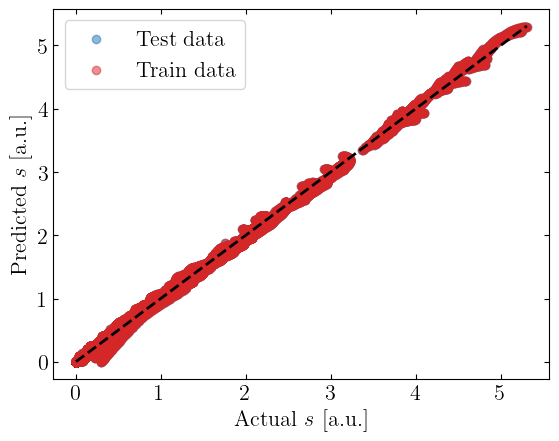

In [ ]:
import_reload()
model_s = SR_lib.run_symbolic_regression(Xs_train, Ys_train, model = None,run_id = f's_{RUN_ID}', its = ITS, selection = SELECTION, elem = 's')
df_model_s = model_s.equations_
SR_lib.print_models(df_model_s)
SR_lib.print_best_model(model_s, s = True)
SR_lib.pareto_plot(model_s)
SR_lib.parity_plot('s',model_s, X_test = Xs_test,Y_test = Y_test_dict,X_train = Xs_train,Y_train = Y_train_dict, data_set = 'both')

In [25]:
MODEL_DICT = {
    'R0': model_R0,
    'R1': model_R1,
    'C1': model_C1,
    'k':  model_k,
    'sdot':  model_s
}

In [26]:
# def plot_soc(models, df_samples):
#     C_fixed = df_samples['C'].iloc
#     u_per_fixed = traj['u_per']
#     soc = traj['soc'].values

#     f, ax = plt.subplots(1, N_VAR, figsize=(4*N_VAR, N_VAR*4/5))

#     for var in VARIABLES:
#         model = models[var]
#         if var == 's':
#             X_plot = np.column_stack((np.full_like(soc, C_fixed), np.full_like(soc, u_per_fixed), soc, np.full_like(soc, REF_VALUES['s'])))
#             Y_true = traj['sdot']
#         else:
#             X_plot = np.column_stack((np.full_like(soc, C_fixed), np.full_like(soc, u_per_fixed), soc))
#             Y_true = traj[var]
#         Y_plot = model.predict(X_plot) * REF_VALUES[var]
#         ax[VARIABLES.index(var)].plot(soc, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs SOC')
#         ax[VARIABLES.index(var)].set_xlabel('SOC')
#         ax[VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
#         ax[VARIABLES.index(var)].plot(soc, Y_true, color=COLORS[VARIABLES.index(var)], linestyle='--', label='True')
#         ax[VARIABLES.index(var)].legend()
#         ax[VARIABLES.index(var)].invert_xaxis()
#     plt.tight_layout()



# traj = get_traj(trajectory_id = 1, test = True)
# plot_soc(MODEL_DICT, traj)

In [27]:
# def plot_d(models):
#     u_per = np.linspace(0,30,1000)
#     C_fixed = 1
#     C = np.linspace(0.5,5,1000)
#     u_fixed = 0
#     soc_fixed = 0.5
#     X_plot1 = np.column_stack((np.full_like(u_per, C_fixed), u_per, np.full_like(u_per, soc_fixed)))
#     X_plot2 = np.column_stack((C, np.full_like(C, u_fixed), np.full_like(C, soc_fixed)))
#     f, ax = plt.subplots(2, N_VAR, figsize=(4*N_VAR, N_VAR*8/5))

        
#     for var in VARIABLES:
#         model = models[var]
#         Y_plot = model.predict(X_plot1) * REF_VALUES[var]
#         ax[0,VARIABLES.index(var)].plot(u_per, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs u_per')
#         ax[0,VARIABLES.index(var)].set_xlabel(r'$\Delta u / L_{tot}$')
#         ax[0,VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
#         ax[0,VARIABLES.index(var)].legend()
#         Y_plot = model.predict(X_plot2) * REF_VALUES[var]
#         ax[1,VARIABLES.index(var)].plot(C, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs u_per')
#         ax[1,VARIABLES.index(var)].set_xlabel(r'C-rate')
#         ax[1,VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
#         ax[1,VARIABLES.index(var)].legend()
        
#     plt.tight_layout()

# plot_d(MODEL_DICT)


In [ ]:
if SAVE:
    SR_lib.save_expressions(df_model_R0, f'R0_{RUN_ID}')
    SR_lib.save_expressions(model_R0.get_best(), f'R0_best_{RUN_ID}')
    SR_lib.save_expressions(df_model_s, f's_{RUN_ID}')
    SR_lib.save_expressions(model_s.get_best(), f's_best_{RUN_ID}')
    SR_lib.save_expressions(df_model_k,  f'k_{RUN_ID}')
    SR_lib.save_expressions(model_k.get_best(), f'k_best_{RUN_ID}')
    SR_lib.save_expressions(df_model_R1, f'R1_{RUN_ID}')
    SR_lib.save_expressions(model_R1.get_best(), f'R1_best_{RUN_ID}')
    SR_lib.save_expressions(df_model_C1, f'C1_{RUN_ID}')
    SR_lib.save_expressions(model_C1.get_best(), f'C1_best_{RUN_ID}')